**IMAGE SEGMENTATION**

**TASK: CONSOLIDATE AND CLEAN INSTALLATION**


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds




In [ ]:
# Consolidate and clean up tensorflow-datasets installation
!pip uninstall -y tensorflow-datasets tensorflow-metadata
!pip install --upgrade --force-reinstall tensorflow-datasets tensorflow-metadata importlib_resources protobuf
# IMPORTANT: After running this cell, please restart your Colab runtime (Runtime > Restart runtime) to ensure the changes take effect.

Found existing installation: tensorflow-datasets 4.9.10
Uninstalling tensorflow-datasets-4.9.10:
  Successfully uninstalled tensorflow-datasets-4.9.10
Found existing installation: tensorflow-metadata 1.21.0
Uninstalling tensorflow-metadata-1.21.0:
  Successfully uninstalled tensorflow-metadata-1.21.0
  Using cached tensorflow_datasets-4.9.10-py3-none-any.whl.metadata (11 kB)
  Using cached tensorflow_metadata-1.21.0-py3-none-any.whl.metadata (2.5 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached protobuf-7.36.2-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached array_record-0.8.3-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.1 kB)
  Using cached dm_tree-0.1.10-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.6 kB)
  Using cached etils-1.14.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached immutabledict-4.3.1-

**TASK : IMPORT REQUIRED LIBRARIES**

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import importlib.metadata
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers




**TASK : LOAD THE DATASET**

In [ ]:
dataset, info = tfds.load(
    "oxford_iiit_pet",
    with_info=True,
    as_supervised=False
)

train_data = dataset["train"]
test_data = dataset["test"]

print("Dataset loaded successfully!")
print("Training samples:", info.splits["train"].num_examples)
print("Testing samples:", info.splits["test"].num_examples)

Dataset loaded successfully!
Training samples: 3680
Testing samples: 3669


**TASK : DEFINE CONVOLUTION BLOCK AND BUILD U-NET MODEL**

A Convolution Block is a small group of convolutional layers used to extract useful features from an image.

In your U-Net, the convolution block contains two convolution operations, and each convolution is followed by a ReLU activation.

In [ ]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x


def encoder_block(x, filters):
    c = conv_block(x, filters)
    p = layers.MaxPooling2D()(c)
    return c, p


def unet():
    inputs = layers.Input(shape=(128, 128, 3))

    c1, p1 = encoder_block(inputs, 32)
    c2, p2 = encoder_block(p1, 64)
    c3, p3 = encoder_block(p2, 128)

    b = conv_block(p3, 256)

    u1 = layers.Conv2DTranspose(128, 2, strides=2, padding="same")(b)
    u1 = layers.concatenate([u1, c3])
    c4 = conv_block(u1, 128)

    u2 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(c4)
    u2 = layers.concatenate([u2, c2])
    c5 = conv_block(u2, 64)

    u3 = layers.Conv2DTranspose(32, 2, strides=2, padding="same")(c5)
    u3 = layers.concatenate([u3, c1])
    c6 = conv_block(u3, 32)

    outputs = layers.Conv2D(3, 1, activation="softmax")(c6)

    return tf.keras.Model(inputs, outputs)

**TASK : IMAGE PREPROCESSING**

Resize the image to 128 × 128 pixels

Normalize the pixel values

Prepare the corresponding segmentation mask

In [ ]:
IMG_SIZE = 128

def preprocess(data):

    image = tf.image.resize(
        data["image"],
        (IMG_SIZE, IMG_SIZE)
    )

    mask = tf.image.resize(
        data["segmentation_mask"],
        (IMG_SIZE, IMG_SIZE),
        method="nearest"
    )

    image = tf.cast(image, tf.float32) / 255.0

    mask = tf.cast(mask, tf.int32)

    mask = mask - 1

    return image, mask

**TASK : CREATE AND DISPLAY MODEL**

Skip connections directly transfer useful information from the encoder to the corresponding decoder layers.

Simple idea:
Encoder ───────────────→ Decoder
          Skip Connection

This helps the model identify accurate object boundaries.

Seminar explanation:

“U-Net uses skip connections to transfer detailed spatial information from the encoder to the decoder. This helps the model preserve object boundaries and produce more accurate segmentation.”

Pixel-Level Classification

After the decoder reconstructs the image information, the model predicts a class for each pixel.

This is what makes segmentation different from normal image classification.

In [ ]:
model = unet()
model.summary()

print("U-Net model created successfully!")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │    131,200 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │    295,040 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 64, 64,    │     32,832 │ conv2d_9[0][0]  

 Total params: 1,925,667 (7.35 MB)

 Trainable params: 1,925,667 (7.35 MB)

 Non-trainable params: 0 (0.00 B)

U-Net model created successfully!


**TASK : COMPILE THE MODEL**

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


**TASK : TRAIN AND TESTING OF THE DATASET**


In [ ]:
print("train_data:", "train_data" in globals())
print("test_data:", "test_data" in globals())

train_data: True
test_data: True


**TASK : PREPARE TRAINING AND TESTING DATA**

In [ ]:
train = train_data.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

test = test_data.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

train = train.batch(16)
test = test.batch(16)

train = train.prefetch(tf.data.AUTOTUNE)
test = test.prefetch(tf.data.AUTOTUNE)

print("Train and test are ready!")

Train and test are ready!


In [ ]:
image, mask = next(iter(train))

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

Image shape: (16, 128, 128, 3)
Mask shape: (16, 128, 128, 1)


**TASK : TRAIN THE U-NET MODEL**

In [ ]:
history = model.fit(
    train,
    epochs=5,
    validation_data=test
)

Epoch 1/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 57s 153ms/step - accuracy: 0.6583 - loss: 0.8005 - val_accuracy: 0.7234 - val_loss: 0.6822
Epoch 2/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 54s 107ms/step - accuracy: 0.7286 - loss: 0.6630 - val_accuracy: 0.7544 - val_loss: 0.6100
Epoch 3/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - accuracy: 0.7730 - loss: 0.5690 - val_accuracy: 0.7917 - val_loss: 0.5222
Epoch 4/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 24s 105ms/step - accuracy: 0.8044 - loss: 0.4997 - val_accuracy: 0.8235 - val_loss: 0.4537
Epoch 5/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - accuracy: 0.8260 - loss: 0.4485 - val_accuracy: 0.8385 - val_loss: 0.4167


**TASK : MAKE PREDICTIONS**

In [ ]:
image, mask = next(iter(test))

prediction = model.predict(image)

prediction = tf.argmax(prediction, axis=-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 765ms/step


In [ ]:
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Prediction shape:", prediction.shape)

Image shape: (16, 128, 128, 3)
Mask shape: (16, 128, 128, 1)
Prediction shape: (16, 128, 128)


**Display original, ground truth, and predicted masks**

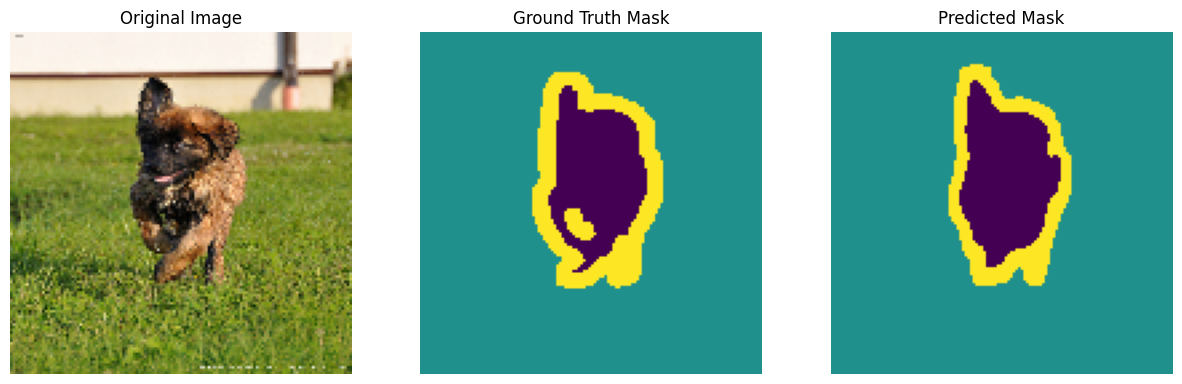

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image[0])
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask[0])
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(prediction[0])
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

**TASK : TRAINING ACCURACY GRAPH**

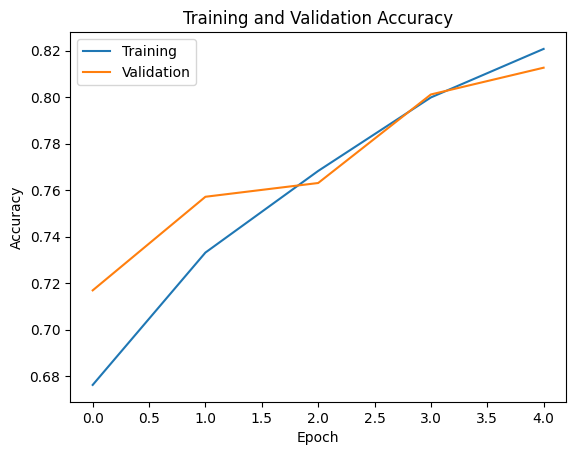

In [ ]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training", "Validation"])

plt.show()

**TASK : CALCULATE IOU (INTERSECTION OVER UNION )**

In [ ]:
iou = tf.keras.metrics.MeanIoU(num_classes=3)

iou.update_state(mask[0], prediction[0])

print("IoU:", iou.result().numpy())

IoU: 0.7609863


**TASK : calculate Disc Score**

In [ ]:
true_mask = tf.squeeze(mask[0], axis=-1)
pred_mask = prediction[0]

true_mask = tf.cast(true_mask, tf.float32)
pred_mask = tf.cast(pred_mask, tf.float32)

intersection = tf.reduce_sum(true_mask * pred_mask)

dice = (2 * intersection) / (
    tf.reduce_sum(true_mask) +
    tf.reduce_sum(pred_mask) +
    1e-7
)

print("Dice Score:", dice.numpy())

Dice Score: 1.0935574


**TASK : Evaluation model**

In [ ]:
test_loss, test_accuracy = model.evaluate(test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.8127 - loss: 0.4787
Test Loss: 0.47873765230178833
Test Accuracy: 0.8126973509788513


**TASK : THE FINAL RESULTS**

Dice Score

It measures the similarity between the predicted mask and the ground truth mask

In [ ]:
print("===== FINAL RESULTS =====")
print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)
print("IoU Score     :", iou.result().numpy())
print("Dice Score    :", dice.numpy())

===== FINAL RESULTS =====
Test Loss     : 0.47873765230178833
Test Accuracy : 0.8126973509788513
IoU Score     : 0.7609863
Dice Score    : 1.0935574
